In [31]:
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

In [32]:
df = pd.read_csv(r'data/vpt_locations.csv')

# Define a function to calculate distance using the Haversine formula
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    r = 6371  # Earth's radius (km)
    return r * c

# Extract location information into lists
locations = df['Location'].tolist()
latitudes = df['Lat'].tolist()
longitudes = df['Lon'].tolist()

# Calculate the distance matrix as a list of lists
distance_matrix = []
for i in range(len(locations)):
    row = []
    for j in range(len(locations)):
        distance = haversine(longitudes[i], latitudes[i], longitudes[j], latitudes[j])
        row.append(distance)
    distance_matrix.append(row)

# Convert the list to a numpy array
distance_matrix = np.array(distance_matrix)

# Save the numpy array as a CSV file
np.savetxt(r'data/distance_matrix.csv', distance_matrix, delimiter=",", fmt='%.6f')



In [33]:
array = np.loadtxt(r'data/demand.csv', delimiter=',')
# print(array.shape)

# Calculate total outflow and inflow for each node
outflow = array.sum(axis=1)
# print(np.sum(outflow))
inflow = array.sum(axis=0)
inflow /= 24

print(np.sum(inflow))
# Calculate outflow ratio for each node
outflow_ratio = array / outflow[:, np.newaxis]
# print(outflow_ratio.shape)

# Save the arrival_rate_vector and choice_probability_matrix 
np.savetxt(r'data/arrival_rate_vector.csv', inflow, delimiter=',', fmt='%.5f')
np.savetxt(r'data/choice_probability_matrix.csv', outflow_ratio, delimiter=',', fmt='%.5f')

def is_irreducible(matrix):
    n = matrix.shape[0]
    reachability = np.copy(matrix)  # Start with the original transition matrix (first power)
    for i in range(2, n+1):  # Compute higher powers of the matrix
        reachability = np.dot(reachability, matrix)
        reachability[reachability > 0] = 1  # Set to 1 if a path exists

    # Check if every state can reach every other state
    return np.all(reachability > 0)

# Check if the Markov chain is irreducible
if is_irreducible(outflow_ratio):
    print("This Markov chain is irreducible.")
else:
    print("This Markov chain is not irreducible.")


3985.5
This Markov chain is irreducible.


In [34]:
import pandas as pd
import numpy as np

# Read choice probability matrix
P = np.loadtxt(r'data/choice_probability_matrix.csv', delimiter=',')
print(P.shape)

# A set of locations
locations = df['Location'].tolist()

# A set of flight corridors (i -> j for all i != j)
flight_corridors = [(i, j) for i in locations for j in locations if i != j]

# A set of all nodes (vertiports + corridors)
nodes = locations + flight_corridors

# Create node index mapping
node_idx = {node: idx for idx, node in enumerate(nodes)}
# print("Node indices:", node_idx)

# Initialize routing matrix
R = np.zeros((len(nodes), len(nodes)))

# Routing matrix
for i_node in nodes:
    for j_node in nodes:
        i_idx = node_idx[i_node]
        j_idx = node_idx[j_node]

        # Case : vertiport -> flight corridor
        if isinstance(i_node, str) and isinstance(j_node, tuple):
            entry, exit = j_node
            if i_node == entry:
                R[i_idx, j_idx] = P[node_idx[entry], node_idx[exit]]

        # Case : flight corridor -> vertiport
        elif isinstance(i_node, tuple) and isinstance(j_node, str):
            entry, exit = i_node
            if j_node == exit:
                R[i_idx, j_idx] = 1

np.savetxt(r'data/routing_matrix.csv', R, delimiter=',', fmt='%.5f')

(10, 10)


In [35]:
import numpy as np
import pandas as pd

# Parameters for UAM travel times
cruise_speed = 241        # Cruise speed in km/h
takeoff_time = 1          # Take-off time in minutes
landing_time = 1          # Landing time in minutes
taxi_time = 2             # Taxi time in minutes

procedure_time = takeoff_time + landing_time + taxi_time*2

# Load the distance matrix
distances = np.loadtxt(r'data/distance_matrix.csv', delimiter=',')

# Compute travel time matrix (in hours)
T = procedure_time / 60 + (distances / cruise_speed)
print(T.shape)

np.savetxt(r'data/travel_time_matrix.csv', T, delimiter=',', fmt='%.5f')

(10, 10)


In [36]:
# Load routing matrix R
R = np.loadtxt(r'data/routing_matrix.csv', delimiter=',')

# Compute left eigenvectors of R: Solve \pi R = \pi
evals, evecs = np.linalg.eig(R.T)

# Find the eigenvalue closest to 1
idx = np.argmin(np.abs(evals - 1))  

# Extract corresponding eigenvector
pi = np.real(evecs[:, idx])
# print(pi.shape)

np.savetxt(r'data/relative_throughput_vector.csv', pi, delimiter=',', fmt='%.5f')

In [ ]:
import numpy as np
import pandas as pd

# Load vertiport data and define nodes ---
df = pd.read_csv(r'data/vpt_locations.csv')

locations = df['Location'].tolist()
flight_corridors = [(i, j) for i in locations for j in locations if i != j]
nodes = locations + flight_corridors
node_idx = {node: idx for idx, node in enumerate(nodes)}
loc_index = {loc: idx for idx, loc in enumerate(locations)}

# Load data 
R = np.loadtxt(r'data/routing_matrix.csv', delimiter=',') # shape (|N|,|N|)
T = np.loadtxt(r'data/travel_time_matrix.csv', delimiter=',') # shape (|V|,|V|)
D = np.loadtxt(r'data/distance_matrix.csv', delimiter=',') # shpae (|V|,|V|)

lambda_vec = np.loadtxt(r'data/arrival_rate_vector.csv', delimiter=',') # shape (|V|,)
# c_usage_vec = np.loadtxt(r'data/c_usage_vector.csv', delimiter=',') # shape (|V|,)
c_usage_vec = np.ones(len(locations))
pi_vec = np.loadtxt(r'data/relative_throughput_vector.csv', delimiter=',') # shape (|N|,)

# Input Parameters
tol = 0.5 # minimum vehicle availability 
c_fare = 2000 # ticket fare in KRW/km
c_penalty = 10000 # penalty cost in KRW
c_usage = 5000 # vertiport usage fee in KRW/ops
c_mnt = 2500 # maintenance cost in KRW/veh
lambda_total = 200 # arrival rate of paasengers who use UAM modes in the system

# Compute c_fare per corridor: distance * 2000 won/km
c_fare_vec = np.array([D[loc_index[i], loc_index[j]] * c_fare for i, j in flight_corridors]) # shape  (|F|,)
c_usage_vec *= c_usage
c_tilde_vec = c_penalty - c_usage_vec
# print(c_tilde_vec)

# Scale arrival rate
lambda_props = lambda_vec / np.sum(lambda_vec)
lambda_vec = lambda_props * lambda_total
# print(lambda_vec)

# Pre-compute base service rates for corridors
n_vpt = len(locations)
n_total = len(nodes)
base_mu = np.zeros(n_total)
for f_idx, (j, k) in enumerate(flight_corridors, start=n_vpt):
    base_mu[f_idx] = 1.0 / T[loc_index[j], loc_index[k]]
# print(base_mu)

# Service Rate 
# Compute mu_i(1) for all nodes
mu_1 = np.zeros(n_total)
mu_1[:n_vpt] = lambda_vec # for vertiports: mu_i(1) = lambda_i
mu_1[n_vpt:] = base_mu[n_vpt:] # for corridors: mu_i(1) = 1 * base_mu_i
# print(mu_n1)

# Compute gamma_base and gamma_tilde for corridors
pi_vpt = pi_vec[:n_vpt] # relative_throughput at vertiports
pi_cdr = pi_vec[n_vpt:] # relative throughput at flight corridors

gamma_base = pi_cdr / mu_1[n_vpt:]

# gamma_tilde_i = gamma_base_i + (sum_{v in V} c_tilde_v * pi_v) / (sum_{f in F} c_fare_f)
numerator = np.dot(c_tilde_vec, pi_vpt)
denominator = np.sum(c_fare)
gamma_vec = gamma_base + numerator / denominator
# print(gamma_vec)

## Exact Solution Search (ESS) Algorithm ###
obj_history = []
n_history = []
availability_history = []

# Initialize MVA state
W = [np.zeros(n_total)] # Response times
L = [np.zeros(n_total)] # Queue lengths
n = 0
m_min = -1
obj_prev = 0

while True:
    n += 1

    # Step 1: MVA response times
    W_vector = np.zeros(n_total)
    for node in nodes:
        idx = node_idx[node]
        if isinstance(node, tuple):
            W_vector[idx] = 1.0 / mu_1[idx]
        else:
            W_vector[idx] = (1.0 + L[n - 1][idx]) / lambda_vec[loc_index[node]]
    Xn = n / np.dot(pi_vec, W_vector)
    L_vector = Xn * pi_vec * W_vector
    W.append(W_vector)
    L.append(L_vector)

    # Step 2: availability check
    availability = [
        Xn * pi_vec[node_idx[loc]] / lambda_vec[loc_index[loc]]
        for loc in locations
    ]
    availability_history.append(availability)
    if m_min == -1 and all(a >= tol for a in availability):
        m_min = n

    # Step 3: objective evaluation
    if m_min != -1 and n >= m_min:
        # new objective:
        # sum_{F} c_fare_i * L_i(n)
        # - sum_{V} c_usage_i * Lambda_i(n)
        # - c_mnt * n
        L_corridors = L_vector[n_vpt:]
        Lambda_vector = Xn * pi_vec
        Lambda_vertiports = Lambda_vector[:n_vpt]

        obj_n = np.dot(c_fare_vec, L_corridors) \
                - np.dot(c_usage_vec, Lambda_vertiports) \
                - c_mnt * n

        n_history.append(n)
        obj_history.append(obj_n)

        if obj_n < obj_prev:
            m_star = n - 1
            break
        obj_prev = obj_n

# --- Results ---
print(f"Minimum fleet size m_min = {m_min}")
print(f"Optimal fleet size m* = {m_star}")
print(f"Obj_val={obj_prev}")

Minimum fleet size m_min = 30
Optimal fleet size m* = 40
Obj_val=75810.92599985853


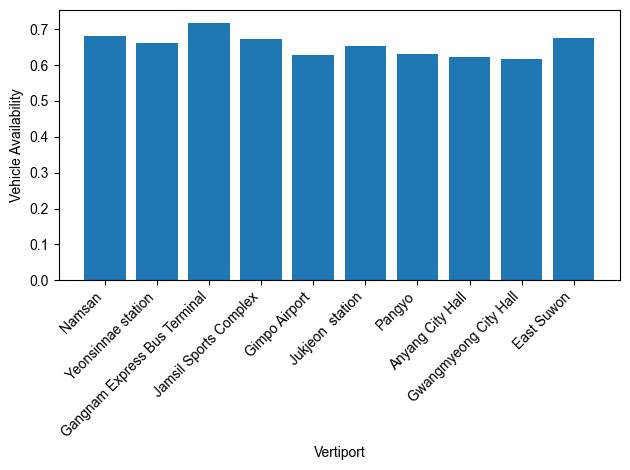

[np.float64(0.6822677652864911), np.float64(0.6618964518741454), np.float64(0.7179893574122853), np.float64(0.6723214360782153), np.float64(0.6276697216662704), np.float64(0.6539864212615953), np.float64(0.6301199270791848), np.float64(0.6213998974051994), np.float64(0.6158854312092515), np.float64(0.6760967220152729)]


In [38]:
import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(n_history, obj_history)
# plt.xlabel('Fleet Size (n)')
# plt.ylabel('Obj(n)')
# # plt.title('Objective vs Fleet Size')
# plt.tight_layout()
# plt.show()

final_availability = availability_history[-1]
plt.figure()
plt.bar(locations, final_availability)
plt.xlabel('Vertiport')
plt.ylabel('Vehicle Availability')
# plt.title(f'Service Availability at Optimal Fleet Size (n={m_star})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
file_name = r"result\fig_veh_availability.png"
plt.savefig(file_name, dpi=600, bbox_inches='tight')
plt.show()

print(final_availability)


Minimum fleet size m_min = 30
Optimal fleet size m* = 80
Objective value = 25962.42487050651


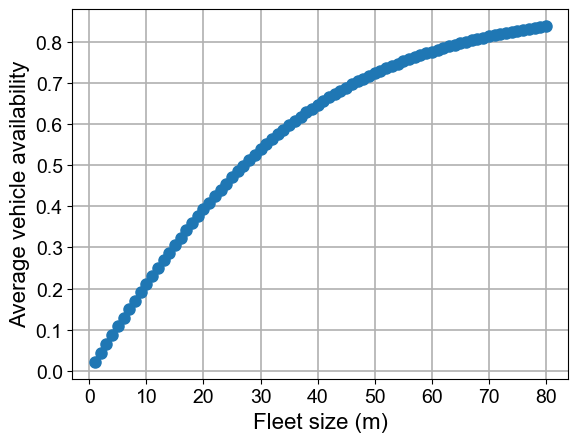

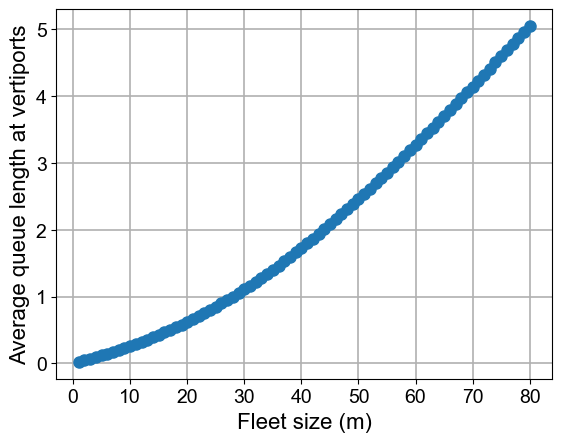

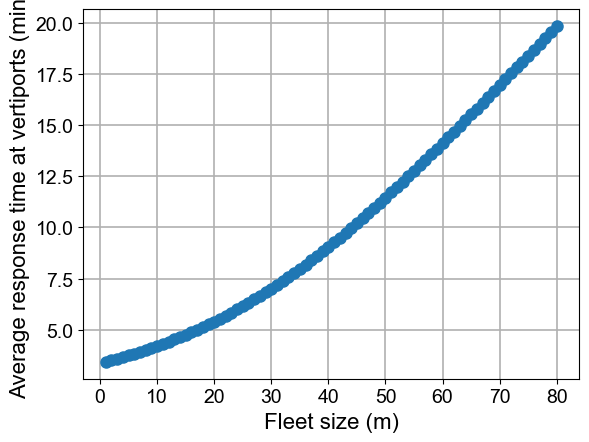

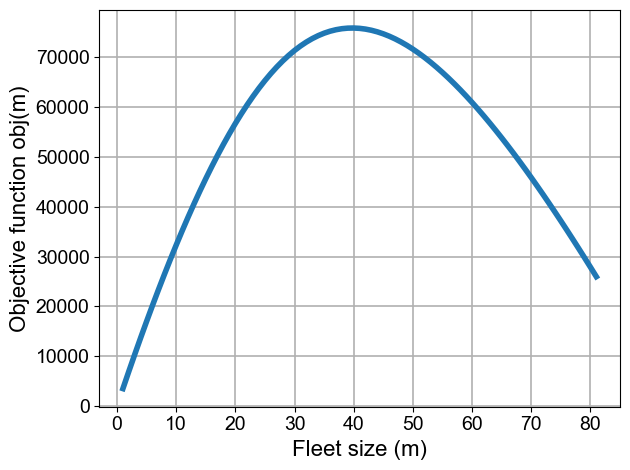

In [39]:
# Load vertiport data and define nodes ---
df = pd.read_csv(r'data/vpt_locations.csv')

locations = df['Location'].tolist()
flight_corridors = [(i, j) for i in locations for j in locations if i != j]
nodes = locations + flight_corridors
node_idx = {node: idx for idx, node in enumerate(nodes)}
loc_index = {loc: idx for idx, loc in enumerate(locations)}

# Load data 
R = np.loadtxt(r'data/routing_matrix.csv', delimiter=',') # shape (|N|,|N|)
T = np.loadtxt(r'data/travel_time_matrix.csv', delimiter=',') # shape (|V|,|V|)
D = np.loadtxt(r'data/distance_matrix.csv', delimiter=',') # shpae (|V|,|V|)

lambda_vec = np.loadtxt(r'data/arrival_rate_vector.csv', delimiter=',') # shape (|V|,)
# c_usage_vec = np.loadtxt(r'data/c_usage_vector.csv', delimiter=',') # shape (|V|,)
c_usage_vec = np.ones(len(locations))
pi_vec = np.loadtxt(r'data/relative_throughput_vector.csv', delimiter=',') # shape (|N|,)

# Input Parameters
tol = 0.5 # minimum vehicle availability 
c_fare = 2000 # ticket fare in KRW/km
c_penalty = 10000 # penalty cost in KRW
c_usage = 5000 # vertiport usage fee in KRW/ops
c_mnt = 2500 # maintenance cost in KRW/veh
lambda_total = 200 # arrival rate of paasengers who use UAM modes in the system

# Compute c_fare per corridor: distance * 2000 won/km
c_fare_vec = np.array([D[loc_index[i], loc_index[j]] * c_fare for i, j in flight_corridors]) # shape  (|F|,)
c_usage_vec *= c_usage
c_tilde_vec = c_penalty - c_usage_vec
# print(c_tilde_vec)

# Scale arrival rate
lambda_props = lambda_vec / np.sum(lambda_vec)
lambda_vec = lambda_props * lambda_total
# print(lambda_vec)

# Pre-compute base service rates for corridors
n_vpt = len(locations)
n_total = len(nodes)
base_mu = np.zeros(n_total)
for f_idx, (j, k) in enumerate(flight_corridors, start=n_vpt):
    base_mu[f_idx] = 1.0 / T[loc_index[j], loc_index[k]]
# print(base_mu)

# Service Rate 
# Compute mu_i(1) for all nodes
mu_1 = np.zeros(n_total)
mu_1[:n_vpt] = lambda_vec # for vertiports: mu_i(1) = lambda_i
mu_1[n_vpt:] = base_mu[n_vpt:] # for corridors: mu_i(1) = 1 * base_mu_i
# print(mu_n1)

# Compute gamma_base and gamma_tilde for corridors
pi_vpt = pi_vec[:n_vpt] # relative_throughput at vertiports
pi_cdr = pi_vec[n_vpt:] # relative throughput at flight corridors

gamma_base = pi_cdr / mu_1[n_vpt:]

# gamma_tilde_i = gamma_base_i + (sum_{v in V} c_tilde_v * pi_v) / (sum_{f in F} c_fare_f)
numerator = np.dot(c_tilde_vec, pi_vpt)
denominator = np.sum(c_fare)
gamma_vec = gamma_base + numerator / denominator
# print(gamma_vec)

## Exact Solution Search (ESS) Algorithm ###
obj_history = []
n_history = []
availability_history = []
avg_availability_history = []

# Initialize MVA state
W = [np.zeros(n_total)] # Response times
L = [np.zeros(n_total)] # Queue lengths
n = 0
m_min = -1
obj_prev = 0

while n<=80:
    n += 1

    # Step 1: MVA response times
    W_vector = np.zeros(n_total)
    for node in nodes:
        idx = node_idx[node]
        if isinstance(node, tuple):
            W_vector[idx] = 1.0 / mu_1[idx]
        else:
            W_vector[idx] = (1.0 + L[n - 1][idx]) / lambda_vec[loc_index[node]]
    Xn = n / np.dot(pi_vec, W_vector)
    L_vector = Xn * pi_vec * W_vector
    
    A = np.array([
        Xn * pi_vec[node_idx[loc]] / lambda_vec[loc_index[loc]]
        for loc in locations
    ])  # shape (|V|,)

    avg_availability = A.mean()
    avg_availability_history.append(avg_availability)

    W.append(W_vector)
    L.append(L_vector)

    # sum_{F} c_fare_i * L_i(n)
    # - sum_{V} c_usage_i * Lambda_i(n)
    # - c_mnt * n
    
    L_corridors = L_vector[n_vpt:]
    Lambda_vector = Xn * pi_vec
    Lambda_vertiports = Lambda_vector[:n_vpt]

    obj_n = np.dot(c_fare_vec, L_corridors) \
            - np.dot(c_usage_vec, Lambda_vertiports) \
            - c_mnt * n

    n_history.append(n)
    obj_history.append(obj_n)

    if m_min == -1 and all(a >= tol for a in A):
        m_min = n

    if obj_n < obj_prev:
        m_star = n - 1
        # break

    obj_prev = obj_n
    
print(f"Minimum fleet size m_min = {m_min}")
print(f"Optimal fleet size m* = {m_star}")
print(f"Objective value = {obj_prev}")    
    
avg_L_history = []
avg_W_history = []

for m in range(1, m_star+1):
    L_vec = L[m]            
    avg_L_history.append(L_vec[:n_vpt].mean())
    W_vec = W[m]            
    avg_W_history.append((W_vec[:n_vpt]*60).mean())
    
# plt.plot(range(1, m_star+1),avg_availability_history[:m_star], marker='o')
# plt.xlabel('Fleet size (m)')
# plt.ylabel('Average vehicle availabilty')
# plt.grid(True)
# file_name = r"result\fig_avg_veh_availability.png"
# plt.savefig(file_name, dpi=600, bbox_inches='tight')
# plt.show()   

# plt.plot(range(1, m_star+1), avg_L_history, marker='o')
# plt.xlabel('Fleet size (m)')
# plt.ylabel('Average queue length at vertiports')
# plt.grid(True)
# file_name = r"result\fig_avg_queue_length.png"
# plt.savefig(file_name, dpi=600, bbox_inches='tight')
# plt.show()

# plt.plot(range(1, m_star+1), avg_W_history, marker='o')
# plt.xlabel('Fleet size (m)')
# plt.ylabel('Average response time at vertiports (min)')
# plt.grid(True)
# file_name = r"result\fig_avg_response_time.png"
# plt.savefig(file_name, dpi=600, bbox_inches='tight')
# plt.show()
    
# plt.figure()
# plt.plot(n_history, obj_history)
# plt.xlabel('Fleet size (m)')
# plt.ylabel('Objective function obj(m)')
# # plt.title('Objective vs Fleet Size')
# plt.tight_layout()
# file_name = r"result\fig_obj_function.png"
# plt.savefig(file_name, dpi=600, bbox_inches='tight')
# plt.show()


import matplotlib.pyplot as plt

# Global settings for text and line widths
plt.rcParams.update({
    'font.size': 10,
    'font.weight': 'medium',
    'axes.labelweight': 'medium',
    'font.family':   'sans-serif',
    'font.sans-serif': ['Arial'],
})

# 1) Average vehicle availability
plt.figure()
plt.plot(
    range(1, m_star+1),
    avg_availability_history[:m_star],
    marker='o',
    linewidth=3,       # Increase line width
    markersize=8       # Increase marker size
)
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Average vehicle availability', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.savefig(r"result\fig_avg_veh_availability.png", dpi=600, bbox_inches='tight')
plt.show()

# 2) Average queue length
plt.figure()
plt.plot(
    range(1, m_star+1),
    avg_L_history,
    marker='o',
    linewidth=3,
    markersize=8
)
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Average queue length at vertiports', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.savefig(r"result\fig_avg_queue_length.png", dpi=600, bbox_inches='tight')
plt.show()

# 3) Average response time
plt.figure()
plt.plot(
    range(1, m_star+1),
    avg_W_history,
    marker='o',
    linewidth=3,
    markersize=8
)
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Average response time at vertiports (min)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.savefig(r"result\fig_avg_response_time.png", dpi=600, bbox_inches='tight')
plt.show()

# 4) Objective function curve
plt.figure()
plt.plot(
    n_history,
    obj_history,
    linewidth=4
)
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Objective function obj(m)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.tight_layout()
plt.savefig(r"result\fig_obj_function.png", dpi=600, bbox_inches='tight')
plt.show()



In [40]:
# import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(n_history, obj_history)
# plt.xlabel('Fleet size (m)')
# plt.ylabel('Objective function obj(m)')
# # plt.title('Objective vs Fleet Size')
# plt.tight_layout()
# plt.show()


# plt.figure()
# plt.plot(avg_availability_history, n_history)
# plt.xlabel('Average availability $\\bar A(m)$')
# plt.ylabel('Fleet size (m)')
# # plt.title('Objective vs Fleet Size')
# plt.tight_layout()
# plt.show()





Minimum fleet size m_min = 29
Optimal fleet size m* = 38
Objective value = 65336.851649059914


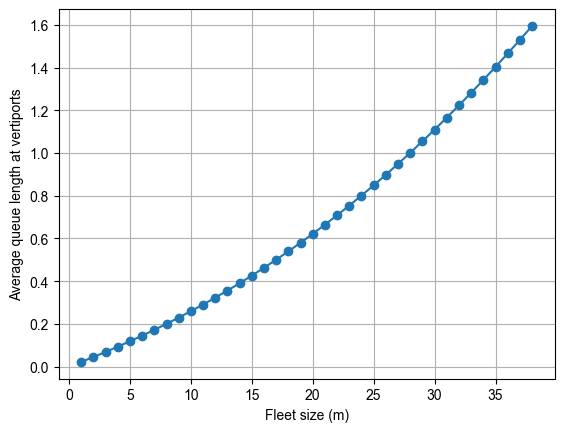

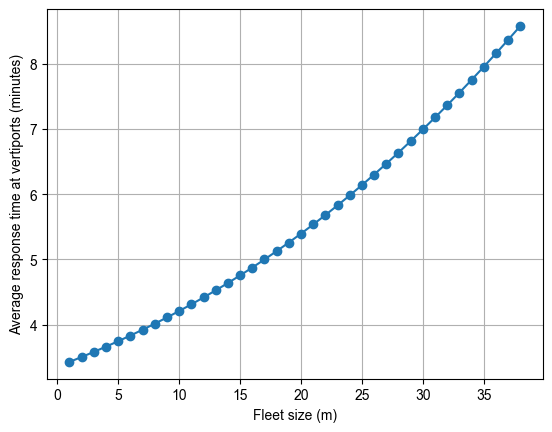

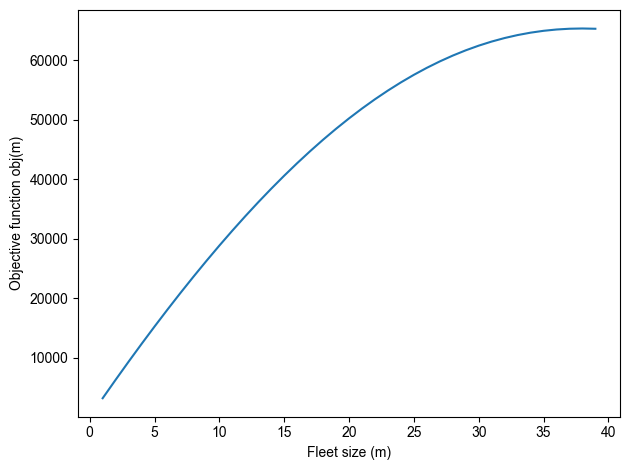

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

# Load vertiport data and define nodes ---
df = pd.read_csv(r'data/vpt_locations.csv')

locations = df['Location'].tolist()
flight_corridors = [(i, j) for i in locations for j in locations if i != j]
nodes = locations + flight_corridors
node_idx = {node: idx for idx, node in enumerate(nodes)}
loc_index = {loc: idx for idx, loc in enumerate(locations)}

# Load data 
R = np.loadtxt(r'data/routing_matrix.csv', delimiter=',') # shape (|N|,|N|)
T = np.loadtxt(r'data/travel_time_matrix.csv', delimiter=',') # shape (|V|,|V|)
D = np.loadtxt(r'data/distance_matrix.csv', delimiter=',') # shpae (|V|,|V|)

lambda_vec = np.loadtxt(r'data/arrival_rate_vector.csv', delimiter=',') # shape (|V|,)
# c_usage_vec = np.loadtxt(r'data/c_usage_vector.csv', delimiter=',') # shape (|V|,)
c_usage_vec = np.ones(len(locations))
pi_vec = np.loadtxt(r'data/relative_throughput_vector.csv', delimiter=',') # shape (|N|,)

# Input Parameters
tol = 0.5 # minimum vehicle availability 
c_fare = 2000 # ticket fare in KRW/km
c_penalty = 10000 # penalty cost in KRW
c_usage = 5000 # vertiport usage fee in KRW/ops
c_mnt = 2500 # maintenance cost in KRW/veh
lambda_total = 200 # arrival rate of paasengers who use UAM modes in the system

# Compute c_fare per corridor: distance * 2000 won/km
c_fare_vec = np.array([D[loc_index[i], loc_index[j]] * c_fare for i, j in flight_corridors]) # shape  (|F|,)
c_usage_vec *= c_usage
c_tilde_vec = c_penalty - c_usage_vec
# print(c_tilde_vec)

# Scale arrival rate
lambda_props = lambda_vec / np.sum(lambda_vec)
lambda_vec = lambda_props * lambda_total
# print(lambda_vec)

# Pre-compute base service rates for corridors
n_vpt = len(locations)
n_total = len(nodes)
base_mu = np.zeros(n_total)
for f_idx, (j, k) in enumerate(flight_corridors, start=n_vpt):
    base_mu[f_idx] = 1.0 / T[loc_index[j], loc_index[k]]
# print(base_mu)

# Service Rate 
# Compute mu_i(1) for all nodes
mu_1 = np.zeros(n_total)
mu_1[:n_vpt] = lambda_vec # for vertiports: mu_i(1) = lambda_i
mu_1[n_vpt:] = base_mu[n_vpt:] # for corridors: mu_i(1) = 1 * base_mu_i
# print(mu_n1)

# Compute gamma_base and gamma_tilde for corridors
pi_vpt = pi_vec[:n_vpt] # relative_throughput at vertiports
pi_cdr = pi_vec[n_vpt:] # relative throughput at flight corridors

gamma_base = pi_cdr / mu_1[n_vpt:]

# gamma_tilde_i = gamma_base_i + (sum_{v in V} c_tilde_v * pi_v) / (sum_{f in F} c_fare_f)
numerator = np.dot(c_tilde_vec, pi_vpt)
denominator = np.sum(c_fare)
gamma_vec = gamma_base + numerator / denominator
# print(gamma_vec)

# --- 2) Gurobi model for rebalancing LP ---
model = gp.Model('rebalancing')
model.Params.OutputFlag = 0  # silent

beta = {}
for i in range(n_vpt):
    for j in range(n_vpt):
        if i != j:
            beta[i, j] = model.addVar(lb=0.0, name=f'beta_{i}_{j}')

model.setObjective(
    gp.quicksum(T[i, j] * beta[i, j] for (i, j) in beta),
    GRB.MINIMIZE
)

for i in range(n_vpt):
    outflow = gp.quicksum(beta[i, j] for j in range(n_vpt) if j != i)
    inflow  = gp.quicksum(beta[j, i] for j in range(n_vpt) if j != i)
    rhs = -lambda_vec[i] + np.dot(P[:, i], lambda_vec)
    model.addConstr(outflow - inflow == rhs)

model.optimize()

# Extract beta_mat, psi, alpha
beta_mat = np.zeros((n_vpt, n_vpt))
for (i, j), var in beta.items():
    beta_mat[i, j] = var.X
psi = beta_mat.sum(axis=1)
alpha = np.zeros_like(beta_mat)
for i in range(n_vpt):
    if psi[i] > 0:
        alpha[i] = beta_mat[i] / psi[i]

# --- 3) Composite arrival rates and routing ---
lambda_tilde = lambda_vec + psi
p_tilde = np.zeros((n_vpt, n_vpt))
for i in range(n_vpt):
    total = lambda_tilde[i]
    if total > 0:
        # compute mixed probabilities for i → j
        for j in range(n_vpt):
            if i != j:
                p_tilde[i, j] = (lambda_vec[i] * P[i, j] + psi[i] * alpha[i, j]) / total
        p_tilde[i, i] = 0.0
        # renormalize row i
        row_sum = p_tilde[i].sum()
        if row_sum > 0:
            p_tilde[i] /= row_sum
        else:
            # fallback to uniform if all zero
            for j in range(n_vpt):
                if i != j:
                    p_tilde[i, j] = 1.0/(n_vpt-1)
            p_tilde[i, i] = 0.0
    else:
        # if no arrivals, copy original probabilities
        p_tilde[i] = P[i].copy()
        p_tilde[i, i] = 0.0
        p_tilde[i] /= p_tilde[i].sum()

# --- 4) Recompute SS stationary distribution ---
eigvals, eigvecs = np.linalg.eig(p_tilde.T)
pi_ss = np.real(eigvecs[:, np.isclose(eigvals, 1.0)].flatten())
pi_ss /= pi_ss.sum()

# --- 5) Build full pi_vec (including corridors) ---
pi_vec_new = np.zeros(n_total)
pi_vec_new[:n_vpt] = pi_ss
for k, (i, j) in enumerate(flight_corridors):
    idx = n_vpt + k
    pi_vec_new[idx] = pi_ss[loc_index[i]] * p_tilde[loc_index[i], loc_index[j]]

# Update service rates and routing for ESS
mu_1[:n_vpt] = lambda_tilde
pi_vec[:] = pi_vec_new

# --- 6) Exact Solution Search (ESS) ---
obj_history, n_history = [], []
availability_history, avg_availability_history = [], []
W = [np.zeros(n_total)]
L = [np.zeros(n_total)]
n = 0
m_min = -1
obj_prev = 0

while n <= 100:
    n += 1
    # MVA: compute response times W_vector
    W_vector = np.zeros(n_total)
    for node in nodes:
        idx = node_idx[node]
        if isinstance(node, tuple):
            W_vector[idx] = 1.0 / mu_1[idx]
        else:
            W_vector[idx] = (1.0 + L[n-1][idx]) / lambda_vec[loc_index[node]]
    Xn = n / np.dot(pi_vec, W_vector)
    L_vector = Xn * pi_vec * W_vector

    # availability at each vertiport
    A = np.array([Xn * pi_vec[node_idx[loc]] / lambda_vec[loc_index[loc]]
                  for loc in locations])
    avg_availability_history.append(A.mean())
    W.append(W_vector)
    L.append(L_vector)

    # objective: fare revenue - usage cost - maintenance cost
    L_corridors = L_vector[n_vpt:]
    Lambda_vertiports = (Xn * pi_vec)[:n_vpt]
    obj_n = np.dot(c_fare_vec, L_corridors) \
            - np.dot(c_usage_vec, Lambda_vertiports) \
            - c_mnt * n

    n_history.append(n)
    obj_history.append(obj_n)

    if m_min == -1 and all(a >= tol for a in A):
        m_min = n
        
    if m_min != -1 and obj_n < obj_prev:
        m_star = n - 1
        break
    obj_prev = obj_n

    # Step 3: objective evaluation
    if m_min != -1 and n >= m_min:
        # new objective:
        # sum_{F} c_fare_i * L_i(n)
        # - sum_{V} c_usage_i * Lambda_i(n)
        # - c_mnt * n
        L_corridors = L_vector[n_vpt:]
        Lambda_vector = Xn * pi_vec
        Lambda_vertiports = Lambda_vector[:n_vpt]

        obj_n = np.dot(c_fare_vec, L_corridors) \
                - np.dot(c_usage_vec, Lambda_vertiports) \
                - c_mnt * n

        n_history.append(n)
        obj_history.append(obj_n)

        if obj_n < obj_prev:
            m_star = n - 1
            break
        obj_prev = obj_n


print(f"Minimum fleet size m_min = {m_min}")
print(f"Optimal fleet size m* = {m_star}")
print(f"Objective value = {obj_prev}")

# --- 7) Plot avg queue length and response time at vertiports ---
avg_L = [L[m][:n_vpt].mean() for m in range(1, m_star+1)]
avg_W = [(W[m][:n_vpt] * 60).mean() for m in range(1, m_star+1)]

plt.figure()
plt.plot(range(1, m_star+1), avg_L, marker='o')
plt.xlabel('Fleet size (m)')
plt.ylabel('Average queue length at vertiports')
plt.grid(True)

plt.figure()
plt.plot(range(1, m_star+1), avg_W, marker='o')
plt.xlabel('Fleet size (m)')
plt.ylabel('Average response time at vertiports (minutes)')
plt.grid(True)

plt.figure()
plt.plot(n_history, obj_history)
plt.xlabel('Fleet size (m)')
plt.ylabel('Objective function obj(m)')
# plt.title('Objective vs Fleet Size')
plt.tight_layout()
plt.show()

plt.show()


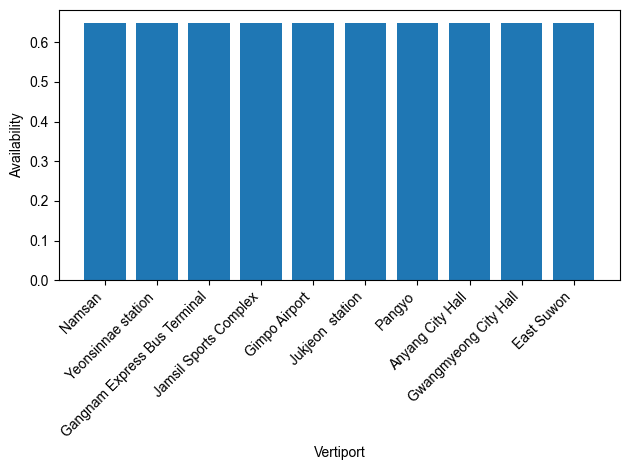

In [42]:
final_availability = A[-1]
plt.figure()
plt.bar(locations, final_availability)
plt.xlabel('Vertiport')
plt.ylabel('Availability')
# plt.title(f'Service Availability at Optimal Fleet Size (n={m_star})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

c_penalty=0: optimal fleet size m*=40, obj*=75810.93
c_penalty=500: optimal fleet size m*=48, obj*=44635.29
c_penalty=1000: optimal fleet size m*=55, obj*=18586.29


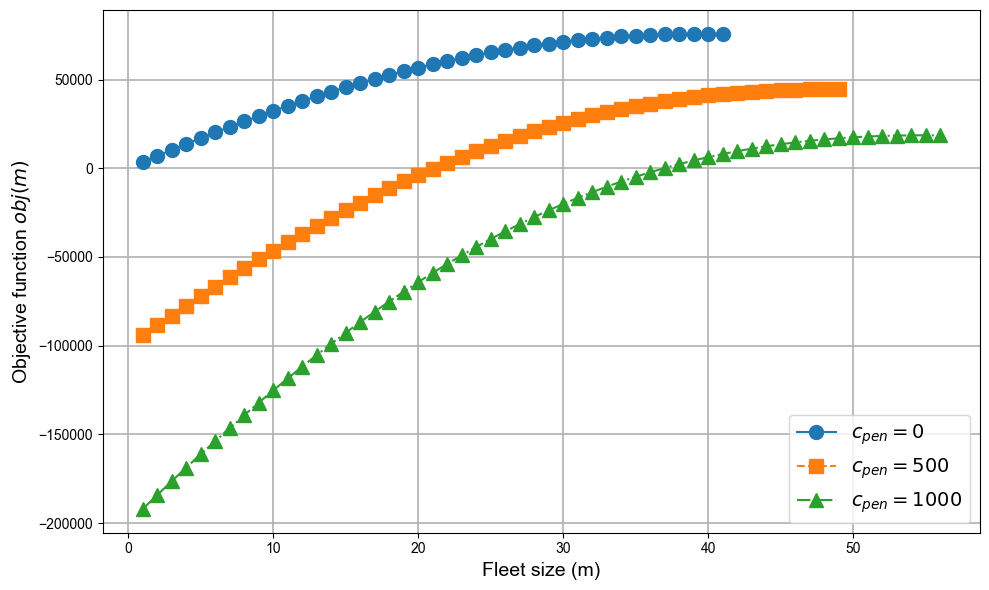

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def exact_solution_search_algorithm(
    c_penalty=0,
    vpt_csv='data/vpt_locations.csv',
    routing_csv='data/routing_matrix.csv',
    time_csv='data/travel_time_matrix.csv',
    dist_csv='data/distance_matrix.csv',
    arrival_csv='data/arrival_rate_vector.csv',
    throughput_csv='data/relative_throughput_vector.csv',
    tol=0.5,
    c_fare=2000,
    c_usage=5000,
    c_mnt=2500,
    lambda_total=200,
    max_m=100
):
    
    # Load data and set up nodes/corridors
    df        = pd.read_csv(vpt_csv)
    locs      = df['Location'].tolist()
    corridors = [(i, j) for i in locs for j in locs if i != j]
    n_vpt     = len(locs)
    n_nodes   = n_vpt + len(corridors)
    loc_idx   = {loc: i for i, loc in enumerate(locs)}
    node_list = locs + corridors
    node_idx  = {node: i for i, node in enumerate(node_list)}

    # Load matrices and vectors
    T          = np.loadtxt(time_csv,    delimiter=',')
    D          = np.loadtxt(dist_csv,    delimiter=',')
    lambda_raw = np.loadtxt(arrival_csv, delimiter=',')
    pi_vec     = np.loadtxt(throughput_csv, delimiter=',')

    # Cost and fare vectors
    c_usage_vec = np.ones(n_vpt) * c_usage
    fare_vec    = np.array([D[loc_idx[i], loc_idx[j]] * c_fare 
                             for i, j in corridors])

    # Scale arrival rates to total
    props      = lambda_raw / lambda_raw.sum()
    lambda_vec = props * lambda_total

    # Compute mu_1 for each node
    base_mu = np.zeros(n_nodes)
    for idx, (i, j) in enumerate(corridors, start=n_vpt):
        base_mu[idx] = 1.0 / T[loc_idx[i], loc_idx[j]]
    mu_1 = np.zeros(n_nodes)
    mu_1[:n_vpt]   = lambda_vec     # vertiports
    mu_1[n_vpt:]   = base_mu[n_vpt:]  # corridors

    # Perform MVA-ESS to build history
    n_history = []
    obj_history = []
    L_prev = np.zeros(n_nodes)
    obj_prev = -np.inf

    for n in range(1, max_m + 1):
        # 1) MVA: compute response times W and queue lengths L
        W = np.zeros(n_nodes)
        for node in node_list:
            idx = node_idx[node]
            if isinstance(node, tuple):
                W[idx] = 1.0 / mu_1[idx]
            else:
                W[idx] = (1 + L_prev[idx]) / lambda_vec[loc_idx[node]]
        Xn = n / np.dot(pi_vec, W)
        L  = Xn * pi_vec * W

        # 2) Compute penalty term from lost arrivals
        A = np.array([Xn * pi_vec[node_idx[loc]] / lambda_vec[loc_idx[loc]] for loc in locs])
        lost_rate = lambda_vec * (1 - A)
        penalty_term = c_penalty * lost_rate.sum()

        # 3) Objective function including penalty
        Lambda_v = Xn * pi_vec[:n_vpt]
        obj = (
            fare_vec.dot(L[n_vpt:])    # fare revenue
          - c_usage_vec.dot(Lambda_v)  # usage fee
          - c_mnt * n                  # maintenance cost
          - penalty_term               # penalty cost
        )

        # 4) Record history
        n_history.append(n)
        obj_history.append(obj)
        L_prev = L

        # 5) Stop if objective decreases
        if obj < obj_prev:
            m_star = n - 1
            break
        obj_prev = obj

    return n_history, obj_history, m_star


# Plotting
penalties   = [0, 500, 1000]
linestyles  = ['-', '--', '-.']
markers     = ['o', 's', '^']

plt.figure(figsize=(10, 6))
for cp, ls, mk in zip(penalties, linestyles, markers):
    n_hist, obj_hist, m_star = exact_solution_search_algorithm(cp)
    # Print optimal results for each penalty
    print(f"c_penalty={cp}: optimal fleet size m*={m_star}, obj*={obj_hist[m_star-1]:.2f}")

    # Plot the objective curve
    plt.plot(
        n_hist, obj_hist,
        linestyle=ls,
        marker=mk,
        markersize=10,
        label=fr'$c_{{pen}}={cp}$'  # LaTeX-formatted legend
    )

# Configure axes and grid
plt.xlabel('Fleet size (m)', fontsize=14)
plt.ylabel('Objective function $obj(m)$', fontsize=14)
# plt.title('Objective vs Fleet Size with Penalty Term\nand Optimal Annotations', fontsize=16)
plt.grid(True, linewidth=1.2)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('result/fig_penalty_scheme')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_obj_history(
    c_penalty,
    vpt_csv='data/vpt_locations.csv',
    routing_csv='data/routing_matrix.csv',
    time_csv='data/travel_time_matrix.csv',
    dist_csv='data/distance_matrix.csv',
    arrival_csv='data/arrival_rate_vector.csv',
    throughput_csv='data/relative_throughput_vector.csv',
    tol=0.5,
    c_fare=2000,
    c_usage=5000,
    c_mnt=2500,
    lambda_total=200,
    max_m=100
):
    # --- Load data and set up ---
    df        = pd.read_csv(vpt_csv)
    locs      = df['Location'].tolist()
    corridors = [(i,j) for i in locs for j in locs if i!=j]
    n_vpt     = len(locs)
    n_nodes   = n_vpt + len(corridors)
    loc_idx   = {loc:i for i,loc in enumerate(locs)}
    node_list = locs + corridors
    node_idx  = {node:i for i,node in enumerate(node_list)}

    T          = np.loadtxt(time_csv,    delimiter=',')
    D          = np.loadtxt(dist_csv,    delimiter=',')
    lambda_raw = np.loadtxt(arrival_csv, delimiter=',')
    pi_vec     = np.loadtxt(throughput_csv, delimiter=',')

    # cost & fare vectors
    c_usage_vec = np.ones(n_vpt) * c_usage
    fare_vec    = np.array([D[loc_idx[i],loc_idx[j]]*c_fare for i,j in corridors])

    # scale arrival rates
    props      = lambda_raw / lambda_raw.sum()
    lambda_vec = props * lambda_total

    # compute mu_1
    base_mu = np.zeros(n_nodes)
    for idx,(i,j) in enumerate(corridors, start=n_vpt):
        base_mu[idx] = 1.0 / T[loc_idx[i], loc_idx[j]]
    mu_1 = np.zeros(n_nodes)
    mu_1[:n_vpt]   = lambda_vec
    mu_1[n_vpt:]   = base_mu[n_vpt:]

    # histories
    n_history    = []
    obj_history  = []
    avgA_history = []
    avgL_history = []
    avgW_history = []

    L_prev   = np.zeros(n_nodes)
    obj_prev = -np.inf

    for n in range(1, max_m+1):
        # 1) MVA response times W & queue lengths L
        W = np.zeros(n_nodes)
        for node in node_list:
            idx = node_idx[node]
            if isinstance(node, tuple):
                W[idx] = 1.0 / mu_1[idx]
            else:
                W[idx] = (1 + L_prev[idx]) / lambda_vec[loc_idx[node]]
        Xn = n / np.dot(pi_vec, W)
        L  = Xn * pi_vec * W

        # 2) average availability
        A = np.array([ Xn*pi_vec[node_idx[loc]]/lambda_vec[loc_idx[loc]] 
                       for loc in locs ])
        avgA = A.mean()

        # 3) avg queue length & response time at vertiports
        avgL = L[:n_vpt].mean()
        avgW = (W[:n_vpt]*60).mean()

        # 4) penalty term
        lost_rate   = lambda_vec * (1 - A)
        penalty_term = c_penalty * lost_rate.sum()

        # 5) objective
        Lambda_v = Xn * pi_vec[:n_vpt]
        obj = (
            fare_vec.dot(L[n_vpt:])     # revenue
          - c_usage_vec.dot(Lambda_v)   # usage fee
          - c_mnt * n                   # maintenance
          - penalty_term                # penalty
        )

        # record
        n_history.append(n)
        obj_history.append(obj)
        avgA_history.append(avgA)
        avgL_history.append(avgL)
        avgW_history.append(avgW)

        L_prev = L
        if obj < obj_prev:
            m_star = n - 1
            break
        obj_prev = obj

    return n_history, obj_history, avgA_history, avgL_history, avgW_history, m_star


# ====================== Plotting ======================
# 3 penalty cases
penalties  = [0, 5000, 10000]
styles     = ['-', '--', '-.']
markers    = ['o', 's', '^']

# apply global style
plt.rcParams.update({
    'font.size':       10,
    'font.weight':     'medium',
    'axes.labelweight':'medium',
    'font.family':     'sans-serif',
    'font.sans-serif': ['Arial'],
})

# prepare containers
all_results = {}
for cp in penalties:
    all_results[cp] = compute_obj_history(cp)


# 1) Average vehicle availability
plt.figure()
for cp, ls, mk in zip(penalties, styles, markers):
    n_hist, _, avgA, *_ , _ = all_results[cp]
    plt.plot(n_hist, avgA, linestyle=ls, marker=mk, markersize=8, label=f'c_penalty={cp}')
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Average vehicle availability', fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("result/fig_avg_veh_availability.png", dpi=600, bbox_inches='tight')
plt.show()

# 2) Average queue length
plt.figure()
for cp, ls, mk in zip(penalties, styles, markers):
    n_hist, _, *_, avgL, _ = all_results[cp]
    plt.plot(n_hist, avgL, linestyle=ls, marker=mk, markersize=8, label=f'c_penalty={cp}')
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Average queue length at vertiports', fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("result/fig_avg_queue_length.png", dpi=600, bbox_inches='tight')
plt.show()

# 3) Average response time
plt.figure()
for cp, ls, mk in zip(penalties, styles, markers):
    n_hist, _, *_, avgW, _ = all_results[cp]
    plt.plot(n_hist, avgW, linestyle=ls, marker=mk, markersize=8, label=f'c_penalty={cp}')
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Average response time at vertiports (min)', fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("result/fig_avg_response_time.png", dpi=600, bbox_inches='tight')
plt.show()

# 4) Objective function curve
plt.figure()
for cp, ls, mk in zip(penalties, styles, markers):
    n_hist, obj_hist, *_, m_star = all_results[cp]
    plt.plot(n_hist, obj_hist, linestyle=ls, marker=mk, markersize=8, label=f'c_penalty={cp}')
plt.xlabel('Fleet size (m)', fontsize=16)
plt.ylabel('Objective function obj(m)', fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.grid(True, linewidth=1.2)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("result/fig_obj_function.png", dpi=600, bbox_inches='tight')
plt.show()
